## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [199]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [200]:
import numpy as np
import pandas as pd

In [201]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [202]:
customer_data.info()

<class 'pandas.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16  N

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [203]:
# Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())

#### A3. Feature engineering

In [204]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [205]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
# Chuyển Dt_Customer sang datetime trước rồi mới lấy năm lớn nhất
dt_series = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')
customer_data['Age'] = dt_series.dt.year.max() - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [206]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')
now = datetime.datetime.now()
reference_date = customer_data['Dt_Customer'].max()
customer_data['Enroll_days'] = (reference_date - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [207]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status_Num'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status_Num'] + customer_data['Kidhome'] + customer_data['Teenhome']

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [208]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = (customer_data['AcceptedCmp1'] + 
                                customer_data['AcceptedCmp2'] + 
                                customer_data['AcceptedCmp3'] + 
                                customer_data['AcceptedCmp4'] + 
                                customer_data['AcceptedCmp5'])

In [209]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = (customer_data['MntWines'] + 
                             customer_data['MntFruits'] + 
                             customer_data['MntMeatProducts'] + 
                             customer_data['MntFishProducts'] + 
                             customer_data['MntSweetProducts'] + 
                             customer_data['MntGoldProds'])

#### A4. Phân tích EDA

In [210]:
customer_data.describe()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Marital_Status_Num,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,45.194196,353.582143,1.644643,2.595089,0.297768,605.798214
min,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,18.000000,0.000000,1.000000,1.000000,0.000000,5.000000
25%,1959.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,37.000000,180.750000,1.000000,2.000000,0.000000,68.750000
50%,1970.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,44.000000,355.500000,2.000000,3.000000,0.000000,396.000000
75%,1977.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,55.000000,529.000000,2.000000,3.000000,0.000000,1045.500000
max,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,121.000000,699.000000,2.000000,5.000000,4.000000,2525.000000
std,11.984069,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.478728,0.906959,0.678381,602.249288


In [211]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

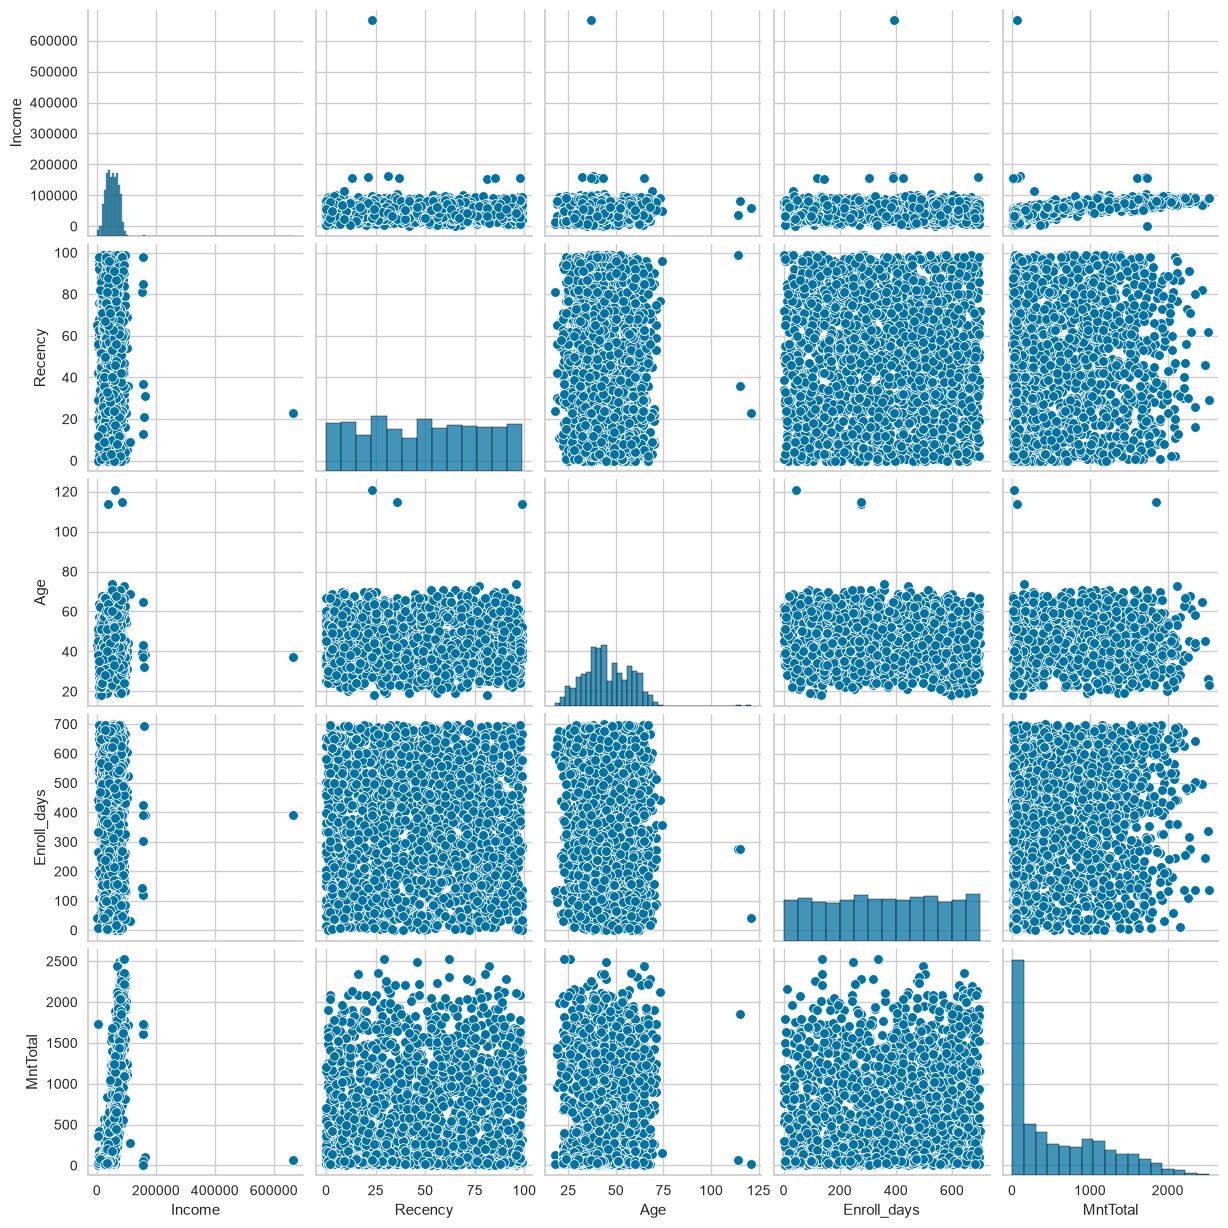

In [212]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
sns.pairplot(customer_data[plot_cols])
plt.show()
# TODO - vẽ pair plot

In [213]:
# TODO - xử lý nhiễu (nếu có)
customer_data = customer_data[(customer_data['Age'] < 90) & (customer_data['Income'] < 600000)]

In [214]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [215]:
# TODO
df = pd.get_dummies(df, drop_first=True)

**Chuẩn hoá các thuộc tính kiểu số**

In [216]:
# TODO
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df = df_scaled.copy()

In [217]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Marital_Status_Num,Fam_Size,MntTotal
count,2.236000e+03,2.236000e+03,2.236000e+03,2236.000000,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03
mean,2.240307e-16,-7.149916e-17,1.271096e-17,0.000000,-7.308803e-17,-1.322734e-16,-1.525315e-16,6.514368e-17,2.542192e-17,9.692108e-17,2.192641e-16,4.766610e-18
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.346560e+00,-1.696543e+00,-1.203575e+00,-1.470716,-9.110556e-01,-1.783046e+00,-2.192136e+00,-2.316276e+00,-1.750171e+00,-1.347635e+00,-1.758810e+00,-9.987636e-01
25%,-7.688934e-01,-8.675502e-01,-6.861374e-01,-0.751127,-9.110556e-01,-8.600834e-01,-9.557071e-01,-6.924366e-01,-8.559730e-01,-1.347635e+00,-6.565959e-01,-8.924037e-01
50%,-1.298227e-02,-4.016436e-03,-1.686996e-01,-0.031538,-2.268842e-01,-2.447750e-01,2.807217e-01,-9.417994e-02,1.101605e-02,7.420405e-01,4.456177e-01,-3.481402e-01
75%,7.620935e-01,8.595173e-01,3.487383e-01,0.688050,4.572872e-01,6.781877e-01,6.928646e-01,8.459377e-01,8.668740e-01,7.420405e-01,4.456177e-01,7.304157e-01
max,5.158923e+00,1.723051e+00,6.557993e+00,8.243731,8.667344e+00,2.216459e+00,6.050723e+00,2.469777e+00,1.707891e+00,7.420405e-01,2.650045e+00,3.189157e+00


#### A6. Phân cụm KMeans

In [218]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

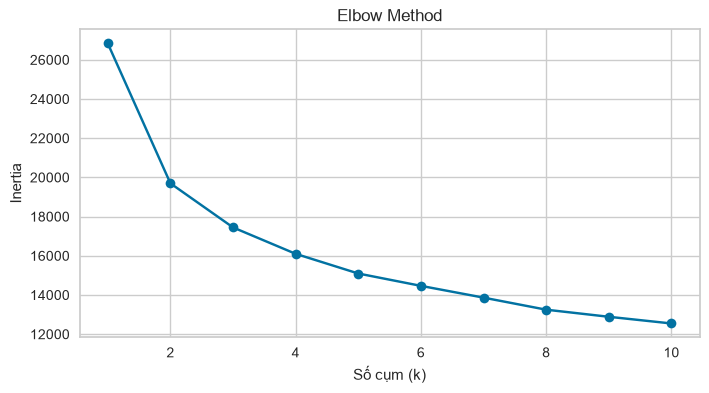

In [219]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [220]:
from yellowbrick.cluster import KElbowVisualizer

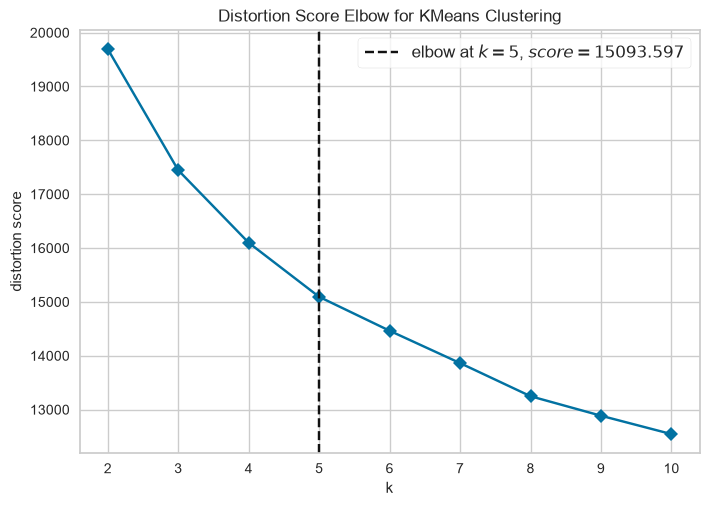

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [221]:
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(2, 11), timings=False, force_model=True)
visualizer.fit(df)
visualizer.show()

**Phân cụm từ kết quả của phương pháp Elbow**

In [222]:
# TODO
kmean = KMeans(n_clusters=4, random_state=42, n_init=10)
kmean.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 12)","[[ 0

**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [223]:
from sklearn.decomposition import PCA

In [224]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO
pca = PCA(n_components=2, random_state=42)
scores = pca.fit_transform(df)

**Trực quan hoá kết quả phân cụm**

In [225]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [226]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Marital_Status_Num,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,663,1,1,0,1617,3
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,113,1,3,0,27,1
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,312,2,2,0,776,3
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,139,2,3,0,53,2
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,161,2,3,0,422,0


In [227]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

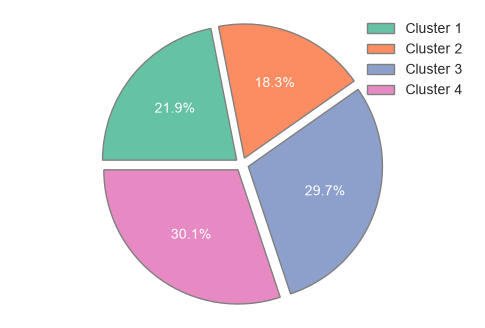

In [228]:
# visualize_cluster_distribution(kmean.labels_)
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

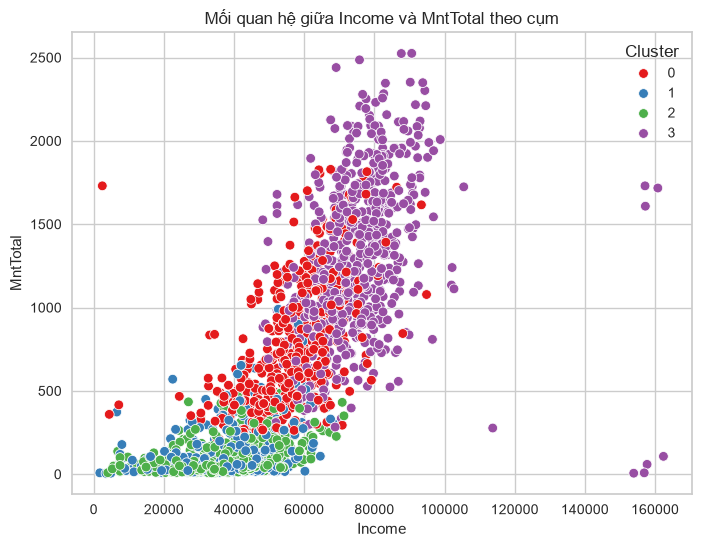

In [229]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Income', y='MntTotal', hue='Cluster', data=kmean_df, palette='Set1')
plt.title('Mối quan hệ giữa Income và MntTotal theo cụm')
plt.show()

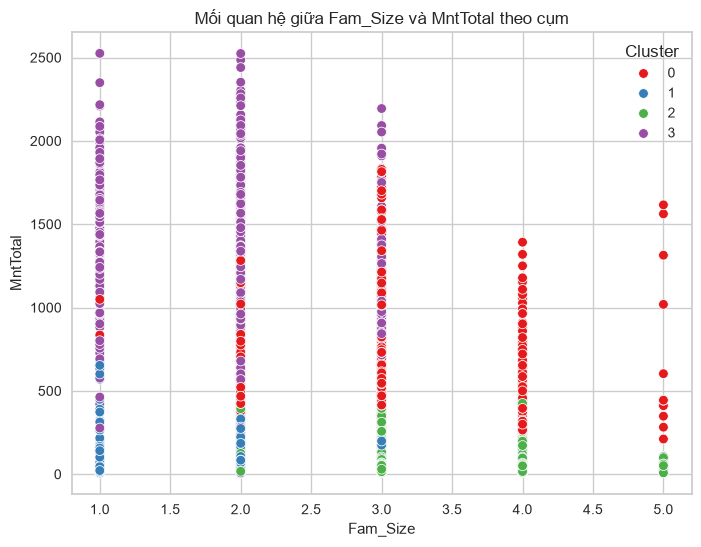

In [230]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Fam_Size', y='MntTotal', hue='Cluster', data=kmean_df, palette='Set1')
plt.title('Mối quan hệ giữa Fam_Size và MntTotal theo cụm')
plt.show()

**Phân tích danh mục mua hàng**

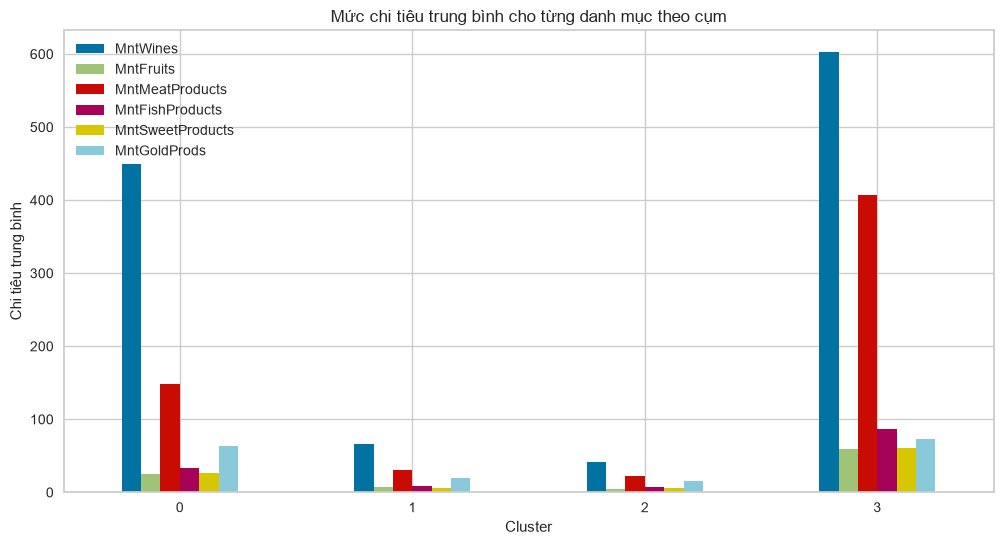

In [231]:
# TODO
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cluster_spending = kmean_df.groupby('Cluster')[mnt_cols].mean()
cluster_spending.plot(kind='bar', figsize=(12, 6))
plt.title('Mức chi tiêu trung bình cho từng danh mục theo cụm')
plt.ylabel('Chi tiêu trung bình')
plt.xticks(rotation=0)
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [232]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

[0.33516119 0.48665456 0.60352524 0.68745589 0.77012326 0.83454226
 0.88461871 0.92296573 0.95065127 0.97291583 0.9889958  1.        ]


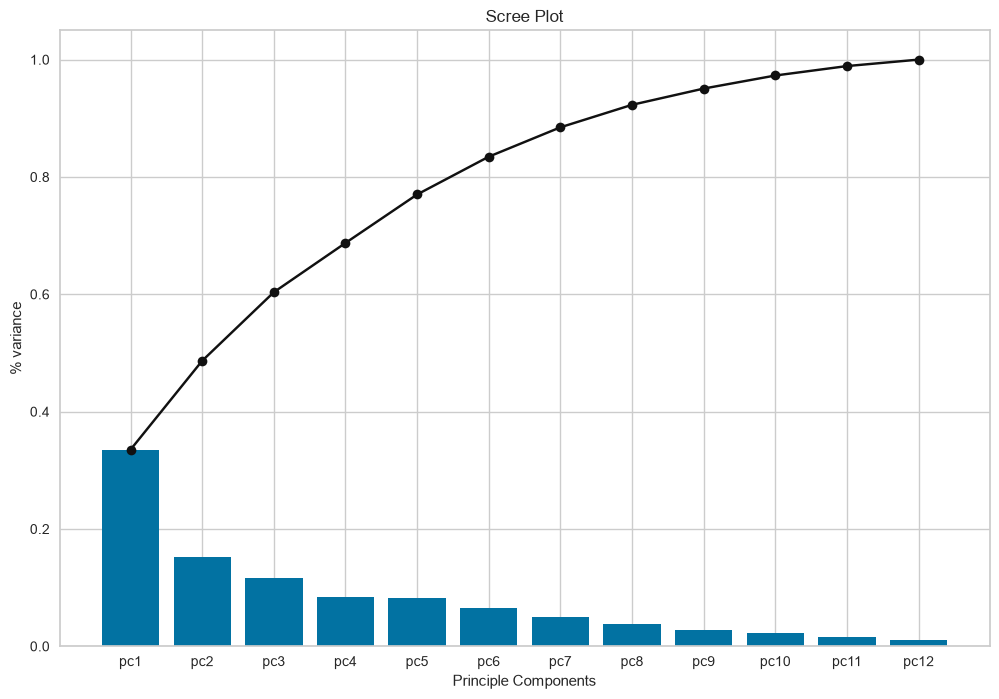

In [233]:
pca_full = PCA(random_state=42).fit(df)   # không đặt n_components
scree_plot(pca_full, [f'pc{i+1}' for i in range(len(df.columns))])

print(np.cumsum(pca_full.explained_variance_ratio_))

In [234]:
# biến đổi df sang không gian pca 4 chiều
# TODO
pca4 = PCA(n_components=4, random_state=42)
pca_transformed_4d = pca4.fit_transform(df)

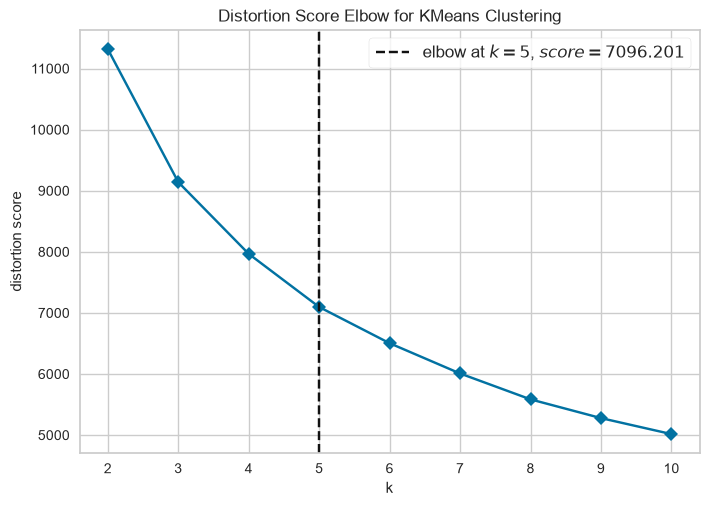

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [235]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=(2, 11), force_model=True, timings=False)
visualizer.fit(pca_transformed_4d)
visualizer.show()

In [236]:
# Số cụm lấy từ elbow (nếu None thì tự chọn theo biểu đồ)
k_pca = visualizer.elbow_value_ or 4
print('k =', k_pca)

kmean_pca = KMeans(n_clusters=k_pca, random_state=42, n_init=10)
kmean_pca.fit(pca_transformed_4d)

k = 5


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",np.int64(5)
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 

In [237]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean_pca.labels_     
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Marital_Status_Num,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,663,1,1,0,1617,1
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,113,1,3,0,27,0
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,312,2,2,0,776,2
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,139,2,3,0,53,0
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,161,2,3,0,422,3


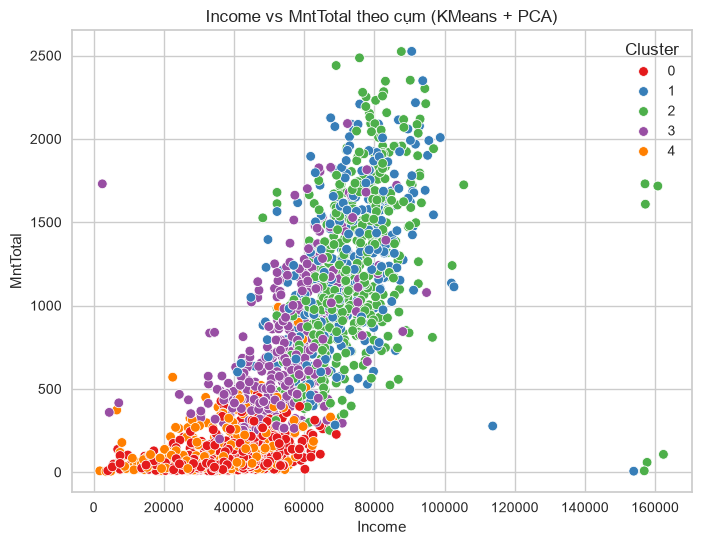

In [238]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Income', y='MntTotal', hue='Cluster',
                data=kmean_pca_df, palette='Set1')
plt.title('Income vs MntTotal theo cụm (KMeans + PCA)')
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [239]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [240]:
len(df.columns)

12

In [241]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    nbrs = NearestNeighbors(n_neighbors=n_neighs).fit(data)
    distances, _ = nbrs.kneighbors(data)
    distances = np.sort(distances[:, -1])      # khoảng cách tới láng giềng xa nhất
    plt.figure(figsize=(8, 4))
    plt.plot(distances)
    plt.xlabel('Điểm (đã sắp xếp)'); plt.ylabel('k-distance')
    plt.grid(True)
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [242]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [243]:
import pandas as pd

In [244]:
df = pd.read_csv('data/taxi_data.csv')
df.head()


,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [245]:
import folium, re

In [ ]:
import folium
import re

for _, row in df.head(500).iterrows():
    name_str = str(row['NAME']) if 'NAME' in row and pd.notna(row['NAME']) else ''
    popup_text = re.sub(r'\W+', ' ', name_str)
    
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=5,
        popup=popup_text,
        fill=True
    ).add_to(m)

title = '<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'
m.get_root().html.add_child(folium.Element(title))

m

In [248]:
m.save('given_data.html')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

df_clean = df.dropna(subset=['LAT', 'LON']).copy()
X = df_clean[['LAT', 'LON']].values

eps = 0.01   
db = DBSCAN(eps=eps, min_samples=5).fit(X)

df_clean['CLUSTER'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)

cmap = plt.colormaps.get_cmap('tab10' if n_clusters <= 10 else 'tab20')
colors = [cmap(i % cmap.N) for i in range(max(n_clusters, 1))]

df_clean['COLOR'] = df_clean['CLUSTER'].apply(
    lambda c: 'black' if c == -1 else colors[c % len(colors)]
)

print(df_clean['CLUSTER'].value_counts())

CLUSTER
-1     288
 9      77
 0      31
 40     26
 31     22
 33     18
 3      17
 30     15
 32     14
 36     14
 23     13
 42     12
 48     12
 11     10
 16     10
 34     10
 39     10
 4       9
 8       9
 19      9
 13      8
 17      8
 18      8
 26      8
 35      8
 44      8
 46      8
 2       7
 7       7
 12      7
 20      7
 21      7
 25      7
 27      7
 28      7
 41      7
 43      7
 45      7
 1       6
 5       6
 6       6
 22      6
 24      6
 29      6
 37      6
 49      6
 10      5
 14      5
 15      5
 38      5
 47      5
 50      5
Name: count, dtype: int64


In [ ]:
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN

eps_km = 0.5  
kms_per_radian = 6371.0
epsilon_rad = eps_km / kms_per_radian
min_samples = 5

coords_rad = np.radians(X)

db = DBSCAN(eps=epsilon_rad, min_samples=min_samples, metric='haversine')

df_clean['CLUSTER'] = db.fit_predict(coords_rad)

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = (df_clean['CLUSTER'] == -1).sum()

print(f"Số lượng cụm tìm được: {n_clusters}")
print(f"Số lượng điểm nhiễu (-1): {n_noise}")
print("\nPhân bố số lượng điểm theo từng cụm:")
print(df_clean['CLUSTER'].value_counts())

Số lượng cụm tìm được: 49
Số lượng điểm nhiễu (-1): 345

Phân bố số lượng điểm theo từng cụm:
CLUSTER
-1     345
 11     59
 36     26
 27     21
 30     18
 26     15
 29     14
 33     14
 8      13
 4      12
 39     12
 45     12
 12     10
 17     10
 31     10
 35     10
 47     10
 3       9
 5       9
 10      9
 19      9
 0       8
 18      8
 37      8
 41      8
 43      8
 2       7
 9       7
 13      7
 14      7
 20      7
 28      7
 23      7
 24      7
 25      7
 32      7
 40      7
 42      7
 1       6
 6       6
 7       6
 21      6
 22      6
 34      6
 15      5
 16      5
 38      5
 44      5
 46      5
 48      5
Name: count, dtype: int64


In [252]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='Stamen Toner',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m